# Traffic Volume Prediction: EDA and Feature Engineering

This notebook covers data collection, exploratory data analysis, data cleaning, and feature engineering
for both the Metro Interstate Traffic Volume dataset and the ERA5 climate dataset.
Processed data is exported to `cleaned data/` for use in `data_modelling.ipynb`.

Datasets used:
- Metro Interstate Traffic Volume (https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
- ERA5 hourly data on single levels from 1940 to present (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)

# 1. Import Modules

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Data Collection
Note that the ERA5 hourly data was requested year-by-year, then converted from .grib to .csv using a custom-written ``grib2csv.py`` script beforehand. Even though this is in fact a significant part of the data cleaning process, the conversion process will be dropped and the data cleaning part will focus on ironing out the final details before use in modeling.

Moreover, the coordinates input for the ERA5 hourly data is determined by locating the coordinates of MN DoT ATR station 301 (specifically Route I-94, Reference post 239+00.922) used in traffic volume data collection from the Roadway Project Mapping Application (https://www.dot.state.mn.us/roadway/data/rpma.html).

In [62]:
traffic = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [63]:
ERA5_2012 = pd.read_csv('ERA5 data (csv)/ERA5_2012.csv')
ERA5_2013 = pd.read_csv('ERA5 data (csv)/ERA5_2013.csv')
ERA5_2014 = pd.read_csv('ERA5 data (csv)/ERA5_2014.csv')
ERA5_2015 = pd.read_csv('ERA5 data (csv)/ERA5_2015.csv')
ERA5_2016 = pd.read_csv('ERA5 data (csv)/ERA5_2016.csv')
ERA5_2017 = pd.read_csv('ERA5 data (csv)/ERA5_2017.csv')
ERA5_2018 = pd.read_csv('ERA5 data (csv)/ERA5_2018.csv')

# Merge all datasets and delete separate dataframes
ERA5 = pd.concat([ERA5_2012, ERA5_2013, ERA5_2014, ERA5_2015, ERA5_2016, ERA5_2017, ERA5_2018],
                 axis=0, ignore_index=True)

del ERA5_2012, ERA5_2013, ERA5_2014, ERA5_2015, ERA5_2016, ERA5_2017, ERA5_2018
ERA5.head()

,t2m,tcc,lcc,mcc,hcc,valid_time,ptype,tp,sf,cp,lsp
0,275.64478,0.945885,0.349785,0.220996,0.924800,2012-01-01 00:00:00,8.0,0.000000,0.000000,0.000000,0.000000
1,274.96802,0.992929,0.787845,0.821806,0.972085,2012-01-01 01:00:00,1.0,0.000077,0.000000,0.000070,0.000008
2,275.06910,1.000000,0.882888,0.981989,0.974361,2012-01-01 02:00:00,1.0,0.000099,0.000000,0.000040,0.000060
3,273.99487,0.999468,0.689093,0.996290,0.954493,2012-01-01 03:00:00,7.0,0.000411,0.000049,0.000118,0.000293
4,274.07740,1.000000,0.914553,1.000000,0.993137,2012-01-01 04:00:00,6.0,0.001072,0.000808,0.000219,0.000853


# 3. Traffic Data (`traffic`)
## 3.1 Data Exploration
### Check NULL and Duplicate Values

In [64]:
traffic.isnull().sum()

traffic_volume             0
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
dtype: int64

There is no NULL values except for holiday, which seems to indicate the lack of holidays.

In [65]:
traffic.duplicated().sum()

17

Let's remove duplicates and change NULL values to 'None':

In [66]:
traffic.drop_duplicates(inplace=True, ignore_index=True)
traffic.holiday = traffic.holiday.fillna('None')

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


### Check Qualitative Variables

In [67]:
traffic.holiday.value_counts()

holiday
None                         48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [68]:
traffic.weather_main.value_counts()

weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [69]:
traffic.weather_description.value_counts()

weather_description
sky is clear                           11659
mist                                    5949
overcast clouds                         5079
broken clouds                           4663
scattered clouds                        3460
light rain                              3372
few clouds                              1956
light snow                              1945
Sky is Clear                            1725
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1099
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             124
heavy intensity drizzle                   64
thunderstorm with heavy rain       

Notice that that there are two separate values denoted "sky is clear" and "Sky is Clear." We'll deal with that later.
### Check Quantitative Variable Distributions

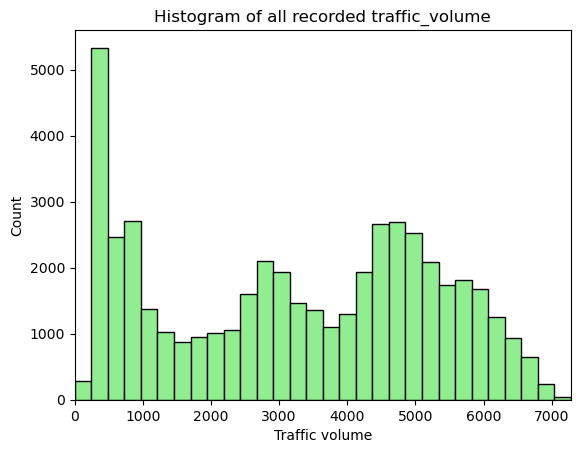

In [70]:
# Traffic volume distribution
plt.title("Histogram of all recorded traffic_volume")
plt.xlim(traffic.traffic_volume.min(), traffic.traffic_volume.max())
plt.xlabel("Traffic volume")
plt.ylabel("Count")

plt.hist(traffic.traffic_volume, color='lightgreen', ec='black', bins=30)

plt.show()

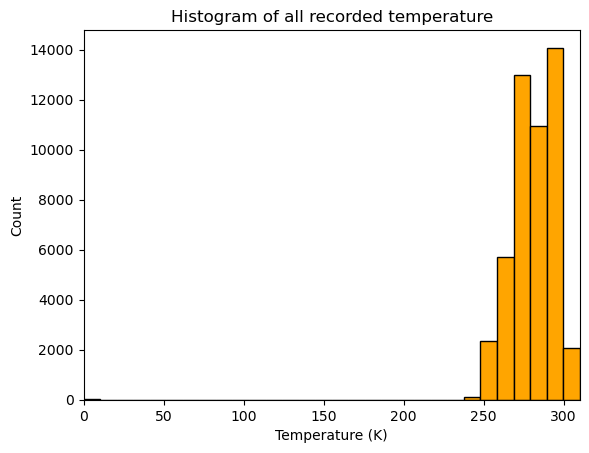

In [71]:
# Temperature distribution
plt.title("Histogram of all recorded temperature")
plt.xlim(traffic.temp.min(), traffic.temp.max())
plt.xlabel("Temperature (K)")
plt.ylabel("Count")

plt.hist(traffic.temp, color='orange', ec='black', bins=30)

plt.show()

It would appear there exists an outlier at T = 0K, which is impossible! 
This is likely a measurement error. Let's try ignoring temperatures below 200K:

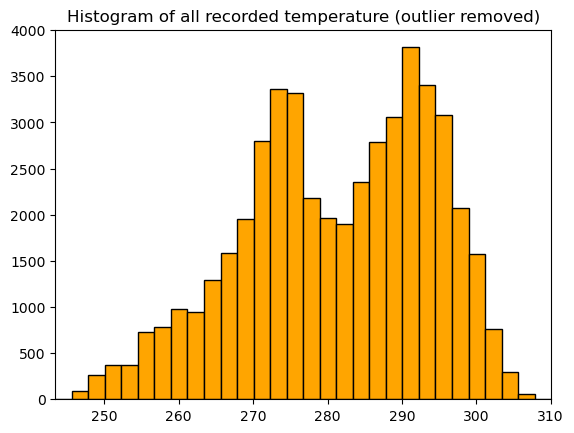

In [72]:
# Temperature distribution
plt.title("Histogram of all recorded temperature (outlier removed)")
plt.xlim(traffic.temp[traffic.temp > 200].min(), traffic.temp.max())
plt.hist(traffic.temp[traffic.temp > 200], color='orange', ec='black', bins=30)

plt.show()

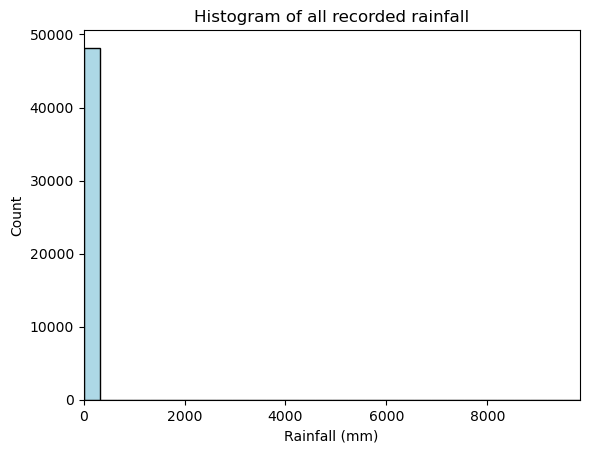

In [73]:
# Rainfall distribution
plt.title("Histogram of all recorded rainfall")
plt.xlim(traffic.rain_1h.min(), traffic.rain_1h.max())
plt.xlabel("Rainfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.rain_1h, color='lightblue', ec='black', bins=30)

plt.show()

Most of the data, as expected, are bunched up at 0mm. There also seems to be data implying the device recorded 10000mm (10m) of rainfall at some point. Let's try removing it.
What if we remove the outlier and scale the y axis logarithmically? Same logic applies for snowfall data.

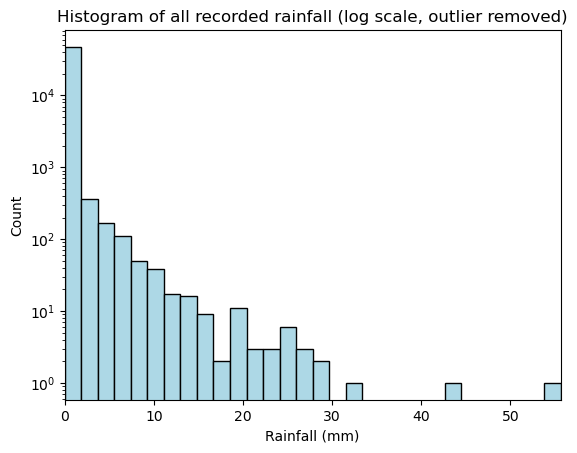

In [74]:
# Rainfall distribution
plt.title("Histogram of all recorded rainfall (log scale, outlier removed)")
plt.xlim(traffic.rain_1h.min(), traffic.rain_1h[traffic.rain_1h < 8000].max())
plt.xlabel("Rainfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.rain_1h[traffic.rain_1h < 8000], color='lightblue', ec='black', bins=30)
plt.yscale('log')

plt.show()

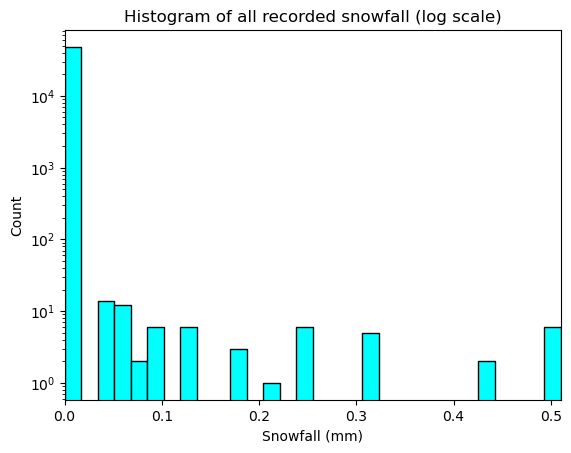

In [75]:
# Snowfall distribution
plt.title("Histogram of all recorded snowfall (log scale)")
plt.xlim(traffic.snow_1h.min(), traffic.snow_1h.max())
plt.xlabel("Snowfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.snow_1h, color='cyan', ec='black', bins=30)
plt.yscale('log')

plt.show()

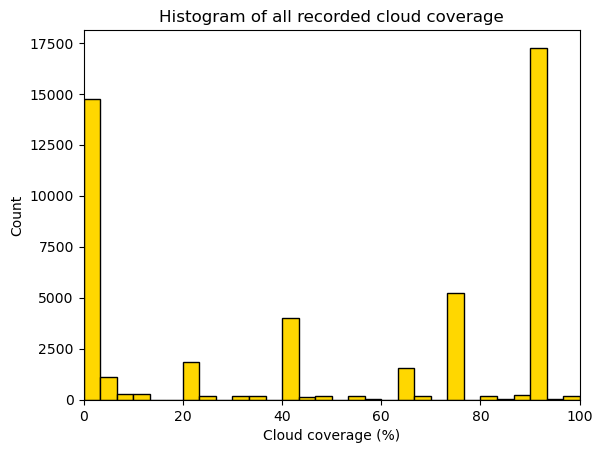

In [76]:
# Cloud coverage distribution
plt.title("Histogram of all recorded cloud coverage")
plt.xlim(traffic.clouds_all.min(), traffic.clouds_all.max())
plt.xlabel("Cloud coverage (%)")
plt.ylabel("Count")

plt.hist(traffic.clouds_all, color='gold', ec='black', bins=30)

plt.show()

In summary, we found outliers in the temperature column and the rainfall column, which will be removed accordingly.
### Check Relationships Between Variables

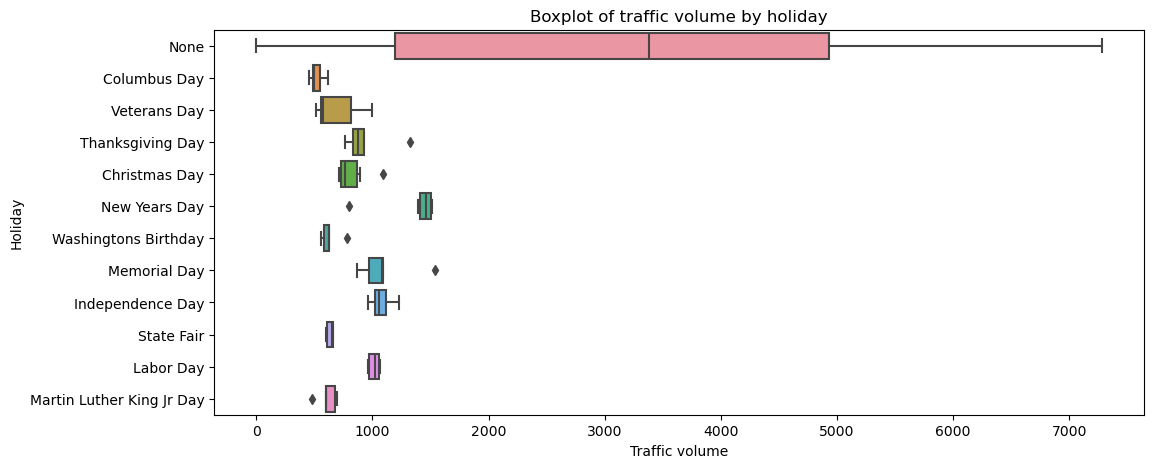

In [77]:
# Traffic volume by holiday
plt.figure(figsize=(12, 5))
sns.boxplot(x='traffic_volume', y='holiday', data=traffic)

plt.title('Boxplot of traffic volume by holiday')
plt.xlabel('Traffic volume')
plt.ylabel('Holiday')

plt.show()

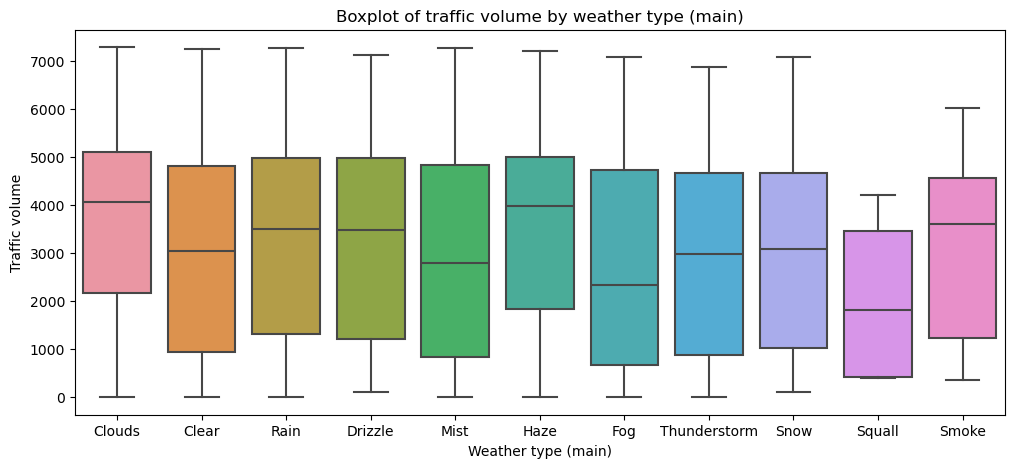

In [78]:
# Traffic volume by weather types
plt.figure(figsize=(12, 5))
sns.boxplot(x='weather_main', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by weather type (main)')
plt.xlabel('Weather type (main)')
plt.ylabel('Traffic volume')

plt.show()

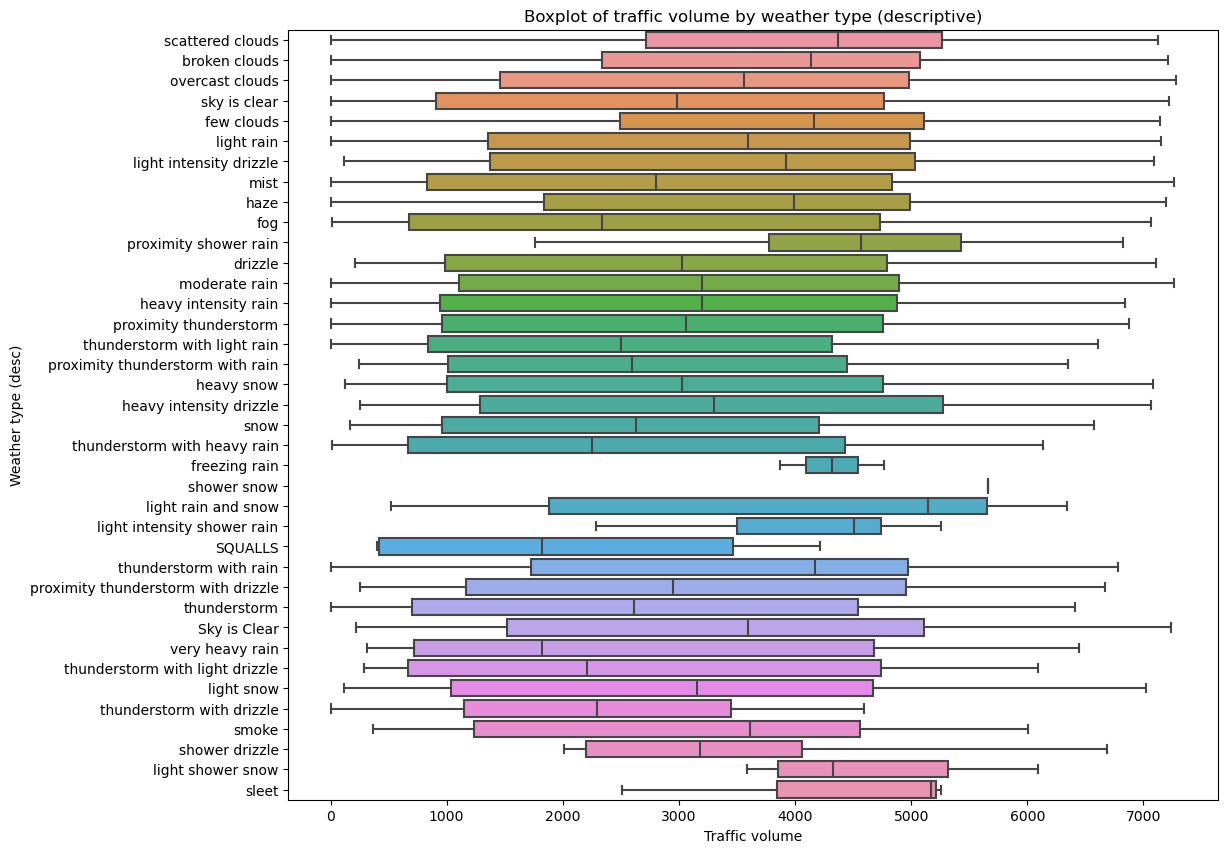

In [79]:
plt.figure(figsize=(12, 10))
sns.boxplot(x='traffic_volume', y='weather_description', data=traffic)

plt.title('Boxplot of traffic volume by weather type (descriptive)')
plt.xlabel('Traffic volume')
plt.ylabel('Weather type (desc)')

plt.show()

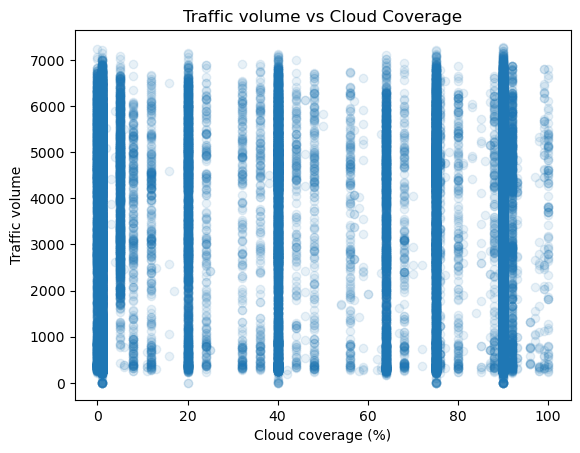

In [80]:
# Traffic volume by cloud coverage
plt.scatter(traffic.clouds_all, traffic.traffic_volume, alpha=0.1)
plt.title('Traffic volume vs Cloud Coverage')

plt.xlabel('Cloud coverage (%)')
plt.ylabel('Traffic volume')

plt.show()

In summary:
- Expect low correlation from cloud coverage.
- Holidays massively reduce traffic volume and different holidays have different impacts.
- Weather conditions DO have an impact on traffic volume. Detailed weather accounts results in more impact variation in traffic volume.
## 3.2 Data Cleaning and Feature Engineering
### Outlier and Duplicate Removal

In [81]:
# Drop all rows with temperature < 200K and precipitation > 8000 mm
traffic.drop(traffic[traffic.temp < 200].index, inplace=True)
traffic.drop(traffic[traffic.rain_1h > 8000].index, inplace=True)
traffic.reset_index(inplace=True, drop=True)

# Rename "Sky is Clear" to "sky is clear"
traffic.weather_description = traffic.weather_description.str.replace('Sky is Clear', 'sky is clear')

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


### One-Hot Encoding for Qualitative Columns

Also, drop 'None' column as it is not used.

In [82]:
# One hot encoding for holiday values
dummy_holiday = pd.get_dummies(traffic.holiday)
dummy_holiday.drop(columns=['None'], inplace=True)

dummy_holiday.head()

,Christmas Day,Columbus Day,Independence Day,Labor Day,Martin Luther King Jr Day,Memorial Day,New Years Day,State Fair,Thanksgiving Day,Veterans Day,Washingtons Birthday
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False


In [83]:
# One hot encoding for holiday weather values (main)
dummy_weaMain = pd.get_dummies(traffic.weather_main)
dummy_weaMain.head()

,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,False,True,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False


In [84]:
# One hot encoding for weather values (descriptive)
dummy_weaDesc = pd.get_dummies(traffic.weather_description)
dummy_weaDesc.head()

,SQUALLS,broken clouds,drizzle,few clouds,fog,freezing rain,haze,heavy intensity drizzle,heavy intensity rain,heavy snow,...,sleet,smoke,snow,thunderstorm,thunderstorm with drizzle,thunderstorm with heavy rain,thunderstorm with light drizzle,thunderstorm with light rain,thunderstorm with rain,very heavy rain
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Parse date_time into Year, Month, Day, Hour, Day of Week

In [85]:
traffic.date_time = pd.to_datetime(traffic.date_time, dayfirst=True)

traffic['year'] = traffic.date_time.dt.year
traffic['month'] = traffic.date_time.dt.month
traffic['day'] = traffic.date_time.dt.day
traffic['hour'] = traffic.date_time.dt.hour
traffic['day_of_week'] = traffic.date_time.dt.day_name()

# Continuous time variables
traffic['hour_cont'] = (
    traffic.date_time.dt.hour
    + traffic.date_time.dt.minute / 60
    + traffic.date_time.dt.second / 3600
)

traffic['dow_cont'] = (
    traffic.date_time.dt.dayofweek
    + traffic['hour_cont'] / 24
)

days_in_month = traffic.date_time.dt.days_in_month

traffic['month_cont'] = (
    (traffic.date_time.dt.month - 1)
    + (traffic.date_time.dt.day - 1
       + traffic['hour_cont'] / 24)
      / days_in_month
)

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,day_of_week,hour_cont,dow_cont,month_cont
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,9,Tuesday,9.0,1.375000,9.044355
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,10,Tuesday,10.0,1.416667,9.045699
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,11,Tuesday,11.0,1.458333,9.047043
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,12,Tuesday,12.0,1.500000,9.048387
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,13,Tuesday,13.0,1.541667,9.049731


### Sin/Cos Harmonic Encoding for Hour, Day of Week, and Month

Instead of one-hot encoding for cyclic time features, we use 5-harmonic sin/cos linear combinations.
This preserves the cyclic nature of the features and reduces dimensionality from 24+7+12=43 columns to 5*2*3=30 columns.

Periods:
- Hour of day: period = 24 hours
- Day of week: period = 7 days (using integer 0=Monday ... 6=Sunday)
- Month of year: period = 12 months

In [86]:
n_harmonics = 5

harmonic_cols = {}

# Hour harmonics (period = 24)
for k in range(1, n_harmonics + 1):
    harmonic_cols[f'hour_sin_{k}'] = np.sin(
        2 * np.pi * k * traffic['hour_cont'] / 24
    )
    harmonic_cols[f'hour_cos_{k}'] = np.cos(
        2 * np.pi * k * traffic['hour_cont'] / 24
    )

# Day-of-week harmonics (period = 7)
for k in range(1, n_harmonics + 1):
    harmonic_cols[f'dow_sin_{k}'] = np.sin(
        2 * np.pi * k * traffic['dow_cont'] / 7
    )
    harmonic_cols[f'dow_cos_{k}'] = np.cos(
        2 * np.pi * k * traffic['dow_cont'] / 7
    )

# Month-of-year harmonics (period = 12)
for k in range(1, n_harmonics + 1):
    harmonic_cols[f'month_sin_{k}'] = np.sin(
        2 * np.pi * k * traffic['month_cont'] / 12
    )
    harmonic_cols[f'month_cos_{k}'] = np.cos(
        2 * np.pi * k * traffic['month_cont'] / 12
    )

dummy_seasonalities = pd.DataFrame(harmonic_cols)

print(f'Shape: {dummy_seasonalities.shape}')
dummy_seasonalities.head()

Shape: (48176, 30)


,hour_sin_1,hour_cos_1,hour_sin_2,hour_cos_2,hour_sin_3,hour_cos_3,hour_sin_4,hour_cos_4,hour_sin_5,hour_cos_5,...,month_sin_1,month_cos_1,month_sin_2,month_cos_2,month_sin_3,month_cos_3,month_sin_4,month_cos_4,month_sin_5,month_cos_5
0,7.071068e-01,-0.707107,-1.000000e+00,-1.836970e-16,7.071068e-01,7.071068e-01,3.673940e-16,-1.0,-7.071068e-01,0.707107,...,-0.999730,0.023222,-0.046432,-0.998921,0.997574,-0.069616,0.092763,0.995688,-0.993266,0.115860
1,5.000000e-01,-0.866025,-8.660254e-01,5.000000e-01,1.000000e+00,1.194340e-15,-8.660254e-01,-0.5,5.000000e-01,0.866025,...,-0.999714,0.023926,-0.047838,-0.998855,0.997425,-0.071722,0.095566,0.995423,-0.992852,0.119354
2,2.588190e-01,-0.965926,-5.000000e-01,8.660254e-01,7.071068e-01,-7.071068e-01,-8.660254e-01,0.5,9.659258e-01,-0.258819,...,-0.999697,0.024629,-0.049243,-0.998787,0.997271,-0.073828,0.098367,0.995150,-0.992426,0.122847
3,1.224647e-16,-1.000000,-2.449294e-16,1.000000e+00,3.673940e-16,-1.000000e+00,-4.898587e-16,1.0,2.388680e-15,-1.000000,...,-0.999679,0.025333,-0.050649,-0.998717,0.997113,-0.075933,0.101168,0.994869,-0.991987,0.126339
4,-2.588190e-01,-0.965926,5.000000e-01,8.660254e-01,-7.071068e-01,-7.071068e-01,8.660254e-01,0.5,-9.659258e-01,-0.258819,...,-0.999661,0.026036,-0.052055,-0.998644,0.996950,-0.078038,0.103969,0.994581,-0.991536,0.129828


### Rearrange Columns

In [87]:
traffic = traffic[['date_time', 'year', 'month', 'day', 'hour', 'day_of_week', 'holiday',
                   'traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
                   'weather_main', 'weather_description']]

traffic.head()

,date_time,year,month,day,hour,day_of_week,holiday,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description
0,2012-10-02 09:00:00,2012,10,2,9,Tuesday,None,5545,288.28,0.0,0.0,40,Clouds,scattered clouds
1,2012-10-02 10:00:00,2012,10,2,10,Tuesday,None,4516,289.36,0.0,0.0,75,Clouds,broken clouds
2,2012-10-02 11:00:00,2012,10,2,11,Tuesday,None,4767,289.58,0.0,0.0,90,Clouds,overcast clouds
3,2012-10-02 12:00:00,2012,10,2,12,Tuesday,None,5026,290.13,0.0,0.0,90,Clouds,overcast clouds
4,2012-10-02 13:00:00,2012,10,2,13,Tuesday,None,4918,291.14,0.0,0.0,75,Clouds,broken clouds


## 3.3 Further Data Exploration

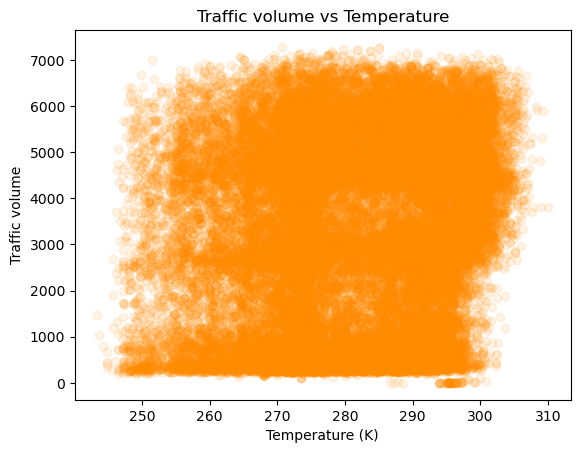

In [88]:
# Traffic volume vs Temperature
plt.scatter(traffic.temp, traffic.traffic_volume, color='darkorange', alpha=0.1)
plt.title('Traffic volume vs Temperature')

plt.xlabel('Temperature (K)')
plt.ylabel('Traffic volume')

plt.show()

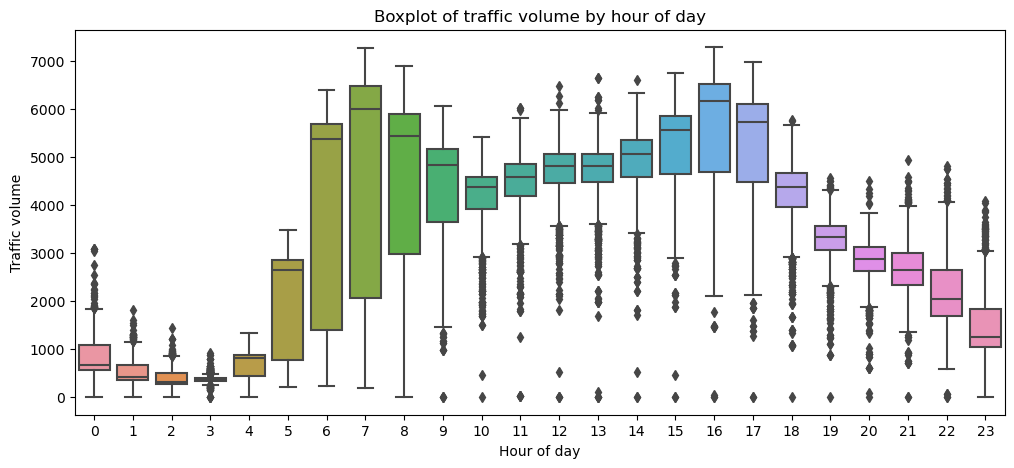

In [89]:
# Average traffic volume by hour of day
plt.figure(figsize=(12, 5))
sns.boxplot(x='hour', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('Traffic volume')

plt.show()

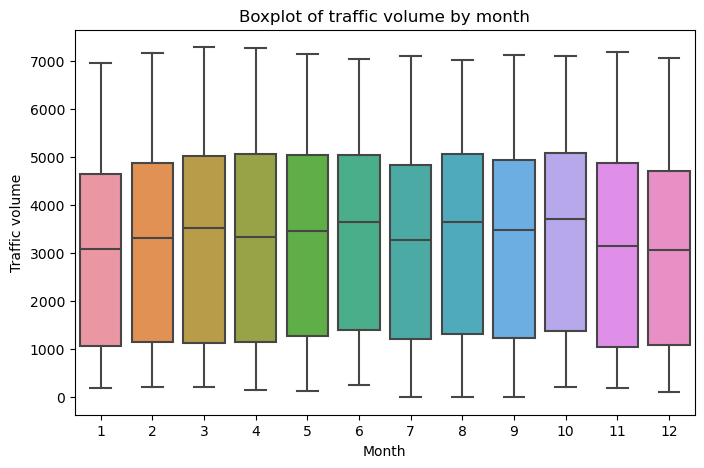

In [90]:
# Average traffic volume by months of the year
plt.figure(figsize=(8, 5))
sns.boxplot(x='month', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by month')
plt.xlabel('Month')
plt.ylabel('Traffic volume')

plt.show()

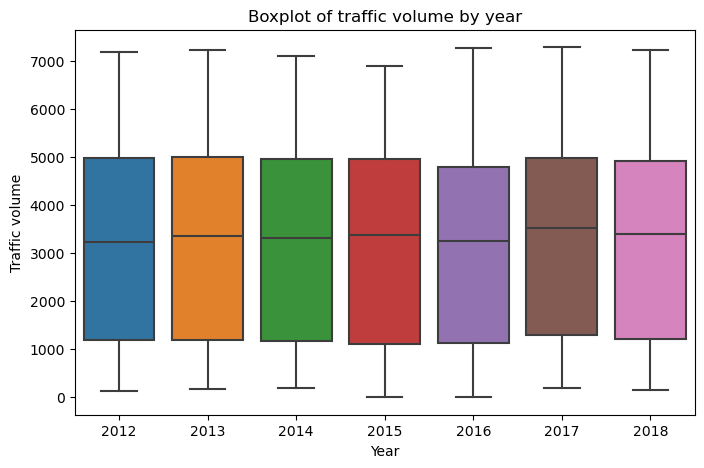

In [91]:
# Average traffic volume by year
plt.figure(figsize=(8, 5))
sns.boxplot(x='year', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by year')
plt.xlabel('Year')
plt.ylabel('Traffic volume')

plt.show()

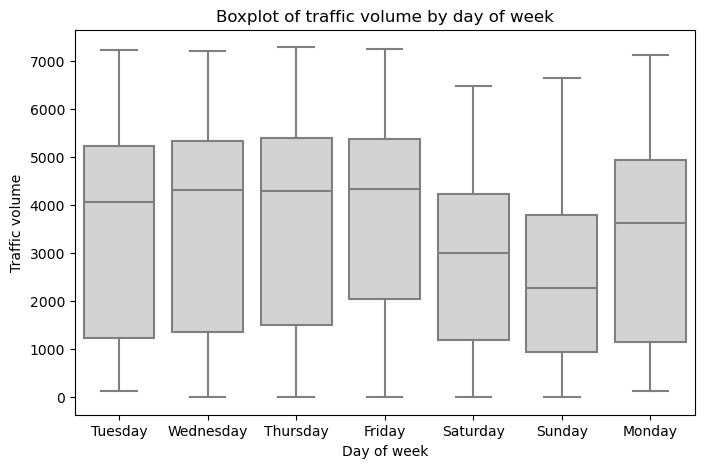

In [92]:
# Average traffic volume by day of the week
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_week', y='traffic_volume', data=traffic, color='lightgrey')

plt.title('Boxplot of traffic volume by day of week')
plt.xlabel('Day of week')
plt.ylabel('Traffic volume')

plt.show()

In summary:
- Expect low correlation from temperature and month of the year.
- Hours massively impact traffic volume, with traffic peaking at rush hours.
- Traffic considerably decreases during weekends, as expected.
- There are no increasing nor decreasing trends per year in this dataset.

# 3.4 Result Analysis Dashboard

This section provides aggregate-level insights derived from the cleaned traffic data.

"Bad weather" is defined as any row where `weather_main` is not 'Clear' or 'Clouds'.

In [93]:
# Define bad weather mask
bad_weather_mask = ~traffic.weather_main.isin(['Clear', 'Clouds'])
traffic['weather_condition'] = np.where(bad_weather_mask, 'Bad weather', 'Good weather')

### Bad Weather vs Good Weather: Average Traffic by Hour

Overall average traffic change during bad weather vs good weather: -11.7%

Hourly % difference (bad - good) / good:
hour
0    -3.8
1    -3.7
2    -3.4
3    -1.4
4     2.1
5     1.3
6    -1.4
7    -2.0
8    -0.4
9    -0.9
10   -1.7
11   -1.8
12   -2.1
13   -1.5
14   -2.2
15   -2.5
16   -4.3
17   -3.2
18   -4.3
19   -6.2
20   -6.6
21   -8.1
22   -8.7
23   -8.4
dtype: float64


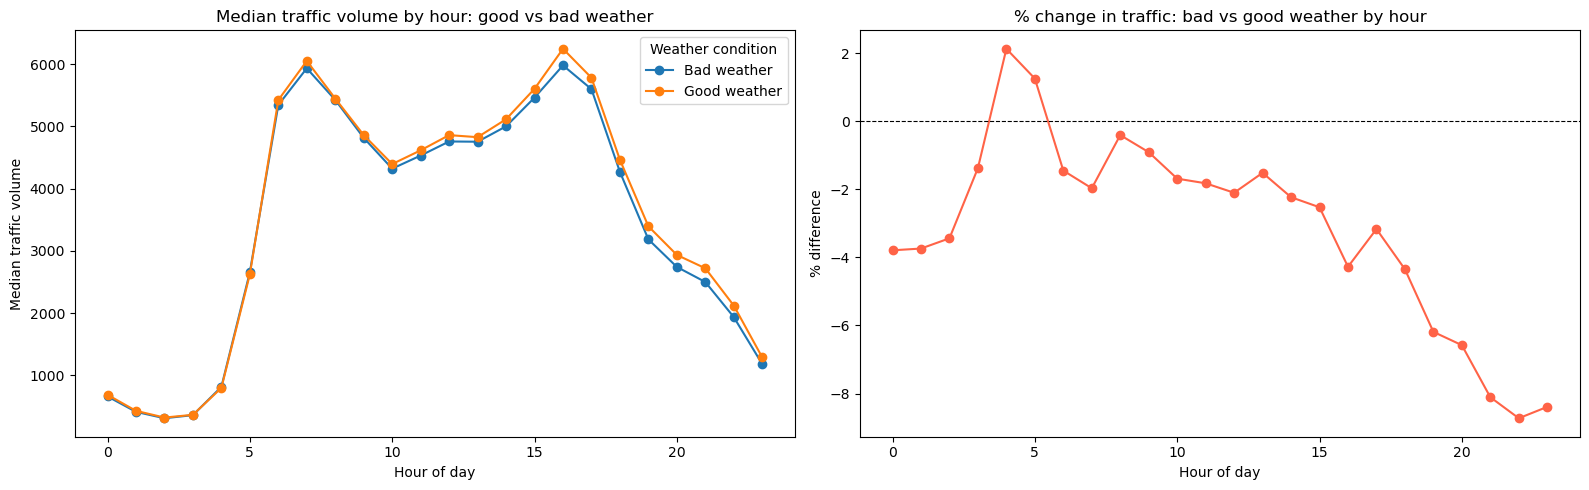

In [94]:
# Aggregate median traffic volume by hour and weather condition
hourly_weather = traffic.groupby(['hour', 'weather_condition'])['traffic_volume'].median().unstack()

# Percent change: bad vs good weather (positive medians bad weather has MORE traffic)
hourly_pct_diff = ((hourly_weather['Bad weather'] - hourly_weather['Good weather'])
                   / hourly_weather['Good weather'] * 100)

overall_pct_diff = ((traffic[bad_weather_mask]['traffic_volume'].median() -
                     traffic[~bad_weather_mask]['traffic_volume'].median()) /
                    traffic[~bad_weather_mask]['traffic_volume'].median() * 100)

print(f'Overall average traffic change during bad weather vs good weather: {overall_pct_diff:.1f}%')
print()
print('Hourly % difference (bad - good) / good:')
print(hourly_pct_diff.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_weather.plot(ax=axes[0], marker='o')
axes[0].set_title('Median traffic volume by hour: good vs bad weather')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Median traffic volume')
axes[0].legend(title='Weather condition')

hourly_pct_diff.plot(ax=axes[1], marker='o', color='tomato')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% change in traffic: bad vs good weather by hour')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('% difference')

plt.tight_layout()
plt.show()

### Holiday vs Non-Holiday: Average Traffic by Day of Week

Overall average traffic change on holidays vs non-holidays: -76.0%

% difference by day of week (holiday - non-holiday) / non-holiday:
day_of_week
Monday      -79.3
Tuesday     -69.9
Wednesday   -79.9
Thursday    -81.4
Friday      -78.6
Saturday      NaN
Sunday        NaN
dtype: float64


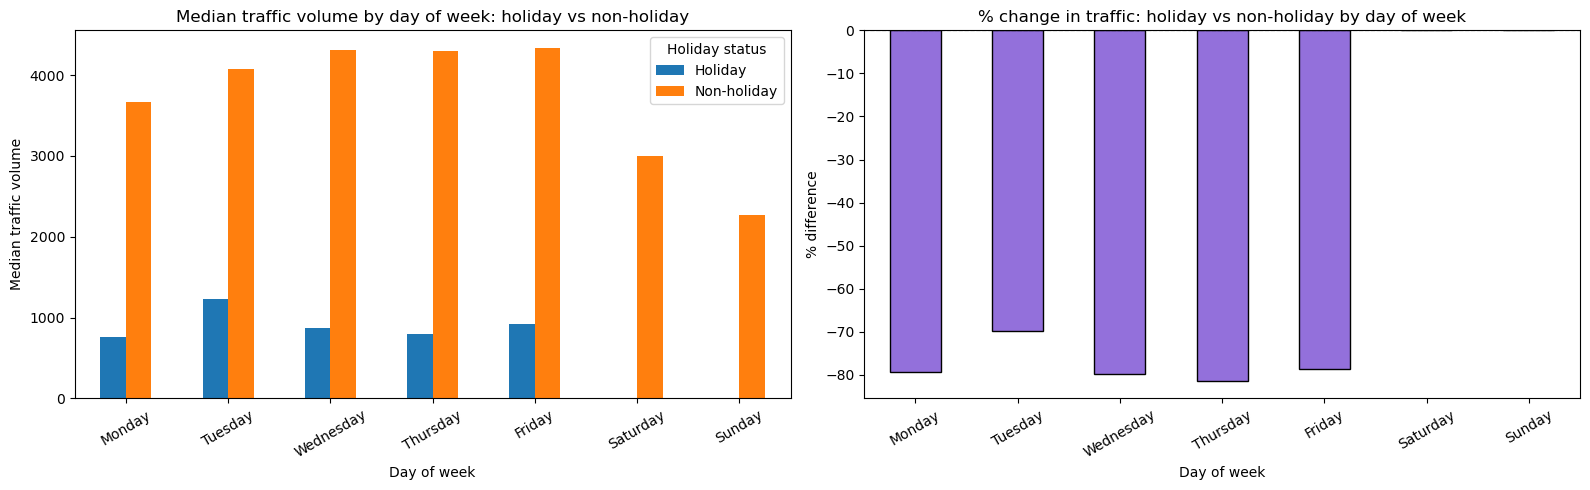

In [95]:
# Define holiday mask
holiday_mask = traffic.holiday != 'None'

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

traffic['is_holiday'] = np.where(holiday_mask, 'Holiday', 'Non-holiday')

dow_holiday = traffic.groupby(['day_of_week', 'is_holiday'])['traffic_volume'].median().unstack()
dow_holiday = dow_holiday.reindex(dow_order)

# Percent change: holiday vs non-holiday (negative = holiday reduces traffic)
dow_pct_diff = ((dow_holiday['Holiday'] - dow_holiday['Non-holiday'])
                / dow_holiday['Non-holiday'] * 100)

overall_holiday_pct = ((traffic[holiday_mask]['traffic_volume'].median() -
                        traffic[~holiday_mask]['traffic_volume'].median()) /
                       traffic[~holiday_mask]['traffic_volume'].median() * 100)

print(f'Overall average traffic change on holidays vs non-holidays: {overall_holiday_pct:.1f}%')
print()
print('% difference by day of week (holiday - non-holiday) / non-holiday:')
print(dow_pct_diff.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_holiday.plot(kind='bar', ax=axes[0])
axes[0].set_title('Median traffic volume by day of week: holiday vs non-holiday')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Median traffic volume')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Holiday status')

dow_pct_diff.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% change in traffic: holiday vs non-holiday by day of week')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('% difference')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Peak vs Off-Peak Hours

Peak hours median traffic volume:      5181
Off-peak hours median traffic volume:  4739
Nighttime median traffic volume:       1117
Peak hours are 9.3% higher than off-peak hours


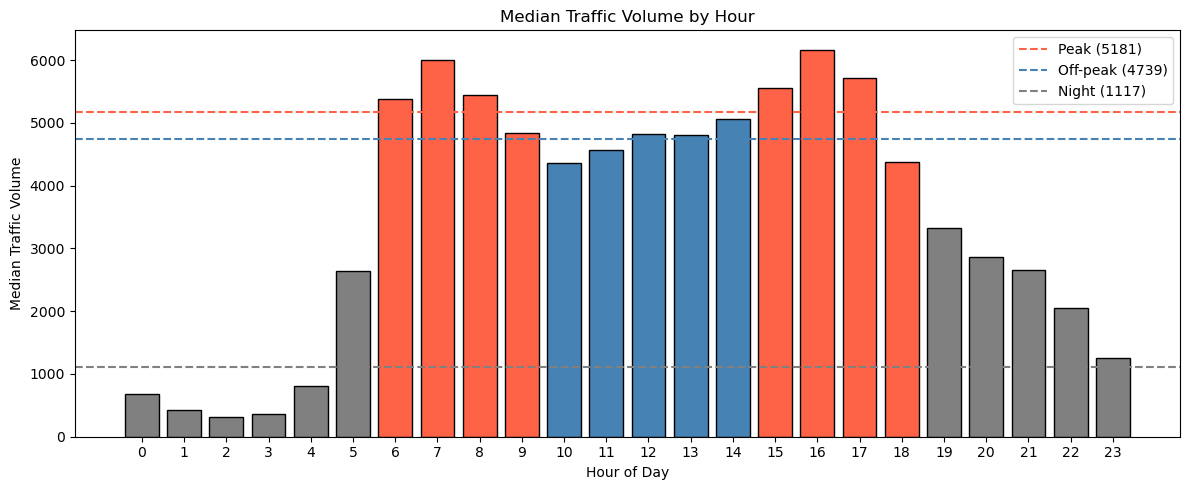

In [122]:
# Define periods
peak_hours = [6, 7, 8, 9, 15, 16, 17, 18]
offpeak_hours = [10, 11, 12, 13, 14, 15]
night_hours = [19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5]

peak_mask = traffic.hour.isin(peak_hours)
offpeak_mask = traffic.hour.isin(offpeak_hours)
night_mask = traffic.hour.isin(night_hours)

peak_avg = traffic.loc[peak_mask, 'traffic_volume'].median()
offpeak_avg = traffic.loc[offpeak_mask, 'traffic_volume'].median()
night_avg = traffic.loc[night_mask, 'traffic_volume'].median()

peak_vs_offpeak_pct = (peak_avg - offpeak_avg) / offpeak_avg * 100

print(f'Peak hours median traffic volume:      {peak_avg:.0f}')
print(f'Off-peak hours median traffic volume:  {offpeak_avg:.0f}')
print(f'Nighttime median traffic volume:       {night_avg:.0f}')
print(f'Peak hours are {peak_vs_offpeak_pct:.1f}% higher than off-peak hours')

# Hourly medians
hourly_median = traffic.groupby('hour')['traffic_volume'].median()

# Color bars by period
bar_colors = []
for h in hourly_median.index:
    if h in peak_hours:
        bar_colors.append('tomato')
    elif h in offpeak_hours:
        bar_colors.append('steelblue')
    else:
        bar_colors.append('gray')

plt.figure(figsize=(12, 5))
plt.bar(hourly_median.index, hourly_median.values,
        color=bar_colors, edgecolor='black')

plt.axhline(peak_avg, color='tomato', linestyle='--',
            label=f'Peak ({peak_avg:.0f})')
plt.axhline(offpeak_avg, color='steelblue', linestyle='--',
            label=f'Off-peak ({offpeak_avg:.0f})')
plt.axhline(night_avg, color='gray', linestyle='--',
            label=f'Night ({night_avg:.0f})')

plt.title('Median Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Median Traffic Volume')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

### Year-on-Year Traffic Growth

Median traffic volume per year:
year
2012    3225.0
2013    3344.0
2014    3319.0
2015    3368.0
2016    3258.0
2017    3529.0
2018    3400.0
Name: traffic_volume, dtype: float64

Year-on-year % growth:
year
2012     NaN
2013    3.69
2014   -0.75
2015    1.48
2016   -3.27
2017    8.32
2018   -3.66
Name: traffic_volume, dtype: float64

Average annual growth rate (excl. first year): 0.36%


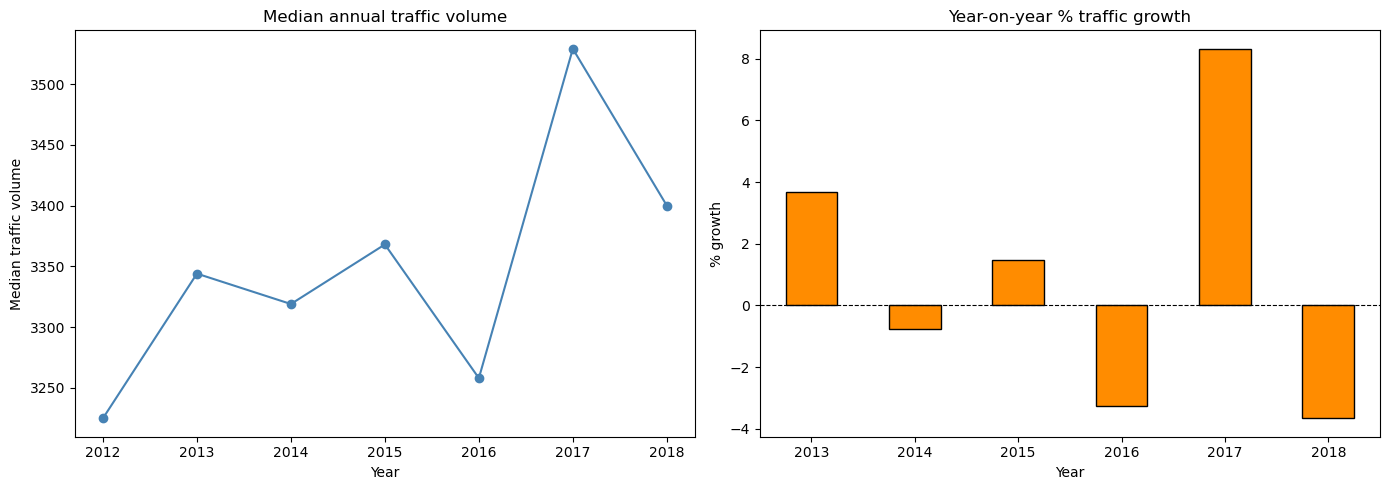

In [97]:
yearly_median = traffic.groupby('year')['traffic_volume'].median()
yoy_growth = yearly_median.pct_change() * 100

print('Median traffic volume per year:')
print(yearly_median.round(0))
print()
print('Year-on-year % growth:')
print(yoy_growth.round(2))
print()
print(f'Average annual growth rate (excl. first year): {yoy_growth.dropna().median():.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_median.plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Median annual traffic volume')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median traffic volume')

yoy_growth.dropna().plot(ax=axes[1], kind='bar', color='darkorange', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Year-on-year % traffic growth')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% growth')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Weekday vs Weekend Traffic

Weekday median traffic: 4094
Weekend median traffic: 2675
Weekend traffic is -34.7% compared to weekdays


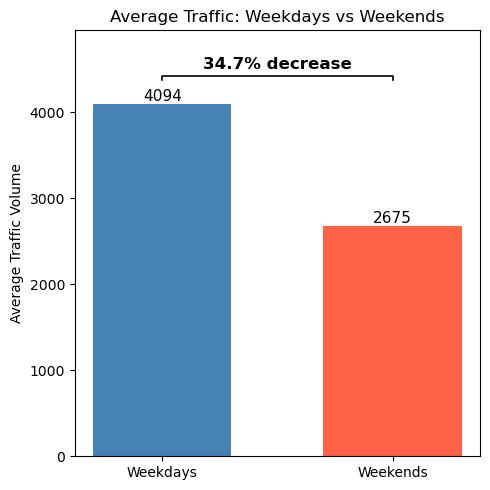

In [98]:
weekend_days = ['Saturday', 'Sunday']
weekend_mask = traffic.day_of_week.isin(weekend_days)

weekday_avg = traffic[~weekend_mask]['traffic_volume'].median()
weekend_avg = traffic[weekend_mask]['traffic_volume'].median()
weekend_pct_diff = (weekend_avg - weekday_avg) / weekday_avg * 100

print(f'Weekday median traffic: {weekday_avg:.0f}')
print(f'Weekend median traffic: {weekend_avg:.0f}')
print(f'Weekend traffic is {weekend_pct_diff:.1f}% compared to weekdays')

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Weekdays', 'Weekends']
values = [weekday_avg, weekend_avg]
colors = ['steelblue', 'tomato']

bars = ax.bar(labels, values, color=colors, width=0.6)

# Value labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

# Percentage difference annotation
y = max(values) * 1.08
ax.plot([0, 0, 1, 1], [y*0.99, y, y, y*0.99], color='black', lw=1.2)

direction = "increase" if weekend_pct_diff >= 0 else "decrease"
ax.text(
    0.5,
    y * 1.01,
    f'{abs(weekend_pct_diff):.1f}% {direction}',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('Average Traffic Volume')
ax.set_title('Average Traffic: Weekdays vs Weekends')
ax.set_ylim(0, y * 1.12)

plt.tight_layout()
plt.show()

# 4. ERA5 Climate Data (`ERA5`)
## 4.1 Data Cleaning and Feature Engineering
### Column Legend

Column name information from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview:
- **t2m:** 2m temperature
- **tcc:** Total cloud cover (0-1)
- **lcc:** Low cloud cover (0-1)
- **mcc:** Medium cloud cover (0-1)
- **hcc:** High cloud cover (0-1)
- **valid_time/date_time:** Specified time
- **ptype:** Precipitation type at surface
- **tp:** Total precipitation, rain and snow, in meters
- **sf:** Snowfall, in meters
- **cp:** Convective precipitation, in meters
- **lsp:** Large-scale precipitation, in meters
- All values in meters will be converted to millimeters during the data cleaning process
### Check NULL Values

In [99]:
print('NULL value count')
print(ERA5.isnull().sum())
print()

print(f'Duplicate count: {ERA5.duplicated().sum()}')
print()

print('INF value count')
print(ERA5.isin([np.inf]).sum(axis=0))

NULL value count
t2m           0
tcc           0
lcc           0
mcc           0
hcc           0
valid_time    0
ptype         0
tp            0
sf            0
cp            0
lsp           0
dtype: int64

Duplicate count: 0

INF value count
t2m           0
tcc           0
lcc           0
mcc           0
hcc           0
valid_time    0
ptype         0
tp            0
sf            0
cp            0
lsp           0
dtype: int64


### Convert Values to Appropriate Formats

In [100]:
# Convert datetime to appropriate format and rename column
ERA5.valid_time = pd.to_datetime(ERA5.valid_time, yearfirst=True)
ERA5.rename(columns={'valid_time': 'date_time'}, inplace=True)

# Rename integer assignments to corresponding categorical values
ERA5.ptype = ERA5.ptype.replace({0: 'None', 
                               1: 'Rain',
                               3: 'Freezing rain',
                               5: 'Snow',
                               6: 'Wet snow',
                               7: 'Rain-snow mix',
                               8: 'Ice pellets'
                              })

# Convert precipitation data from m to mm
ERA5[['tp', 'sf', 'cp', 'lsp']] *= 1000

# Convert to appropriate timezone from UTC to CST (UTC-06:00)
ERA5.date_time = ERA5.date_time - pd.Timedelta(hours=6)

ERA5.head()

,t2m,tcc,lcc,mcc,hcc,date_time,ptype,tp,sf,cp,lsp
0,275.64478,0.945885,0.349785,0.220996,0.924800,2011-12-31 18:00:00,Ice pellets,0.000000,0.000000,0.000000,0.000000
1,274.96802,0.992929,0.787845,0.821806,0.972085,2011-12-31 19:00:00,Rain,0.076868,0.000000,0.069830,0.007533
2,275.06910,1.000000,0.882888,0.981989,0.974361,2011-12-31 20:00:00,Rain,0.099305,0.000000,0.039909,0.059568
3,273.99487,0.999468,0.689093,0.996290,0.954493,2011-12-31 21:00:00,Rain-snow mix,0.410839,0.048706,0.117827,0.292860
4,274.07740,1.000000,0.914553,1.000000,0.993137,2011-12-31 22:00:00,Wet snow,1.072464,0.808361,0.219008,0.853409


### Discard Dates Not in Traffic Dataset

In [101]:
print(f'ERA5 row count (before): {len(ERA5)}')

ERA5 = pd.merge(traffic.date_time, ERA5, on='date_time', how='inner')

print(f'ERA5 row count (after): {len(ERA5)}')

ERA5.head()

ERA5 row count (before): 61368
ERA5 row count (after): 48176


,date_time,t2m,tcc,lcc,mcc,hcc,ptype,tp,sf,cp,lsp
0,2012-10-02 09:00:00,288.61840,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
1,2012-10-02 10:00:00,290.27368,0.020929,0.0,0.0,0.020929,None,0.0,0.0,0.0,0.0
2,2012-10-02 11:00:00,291.98755,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
3,2012-10-02 12:00:00,292.57960,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
4,2012-10-02 13:00:00,293.49878,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0


## 4.2 Data Exploration
### Check Data Distributions

In [102]:
# Check precipitation type distribution
ERA5.ptype.value_counts()

ptype
None             27179
Rain             11070
Snow              8280
Wet snow          1283
Rain-snow mix      246
Ice pellets         67
Freezing rain       51
Name: count, dtype: int64

In [103]:
# Check percentage of weather types with total precipitation going over 0.1 mm
ERA5[ERA5.tp > 0.1].ptype.value_counts() / ERA5.ptype.value_counts() * 100

ptype
Freezing rain    45.098039
Ice pellets      28.358209
None              1.729276
Rain             50.885276
Rain-snow mix    73.983740
Snow             22.173913
Wet snow         40.218239
Name: count, dtype: float64

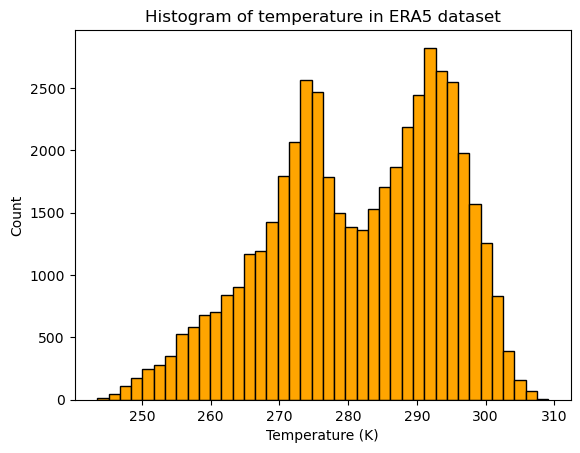

In [104]:
# Tempearature distribution
plt.title("Histogram of temperature in ERA5 dataset")

plt.xlabel("Temperature (K)")
plt.ylabel("Count")

plt.hist(ERA5.t2m, color='orange', ec='black', bins=40)

plt.show()

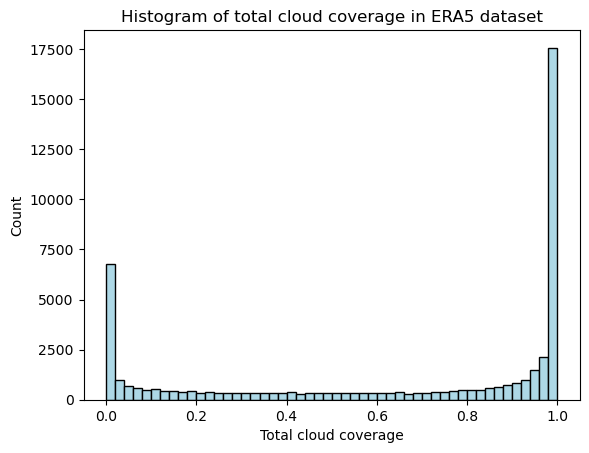

In [105]:
# Cloud coverage distribution
plt.title("Histogram of total cloud coverage in ERA5 dataset")

plt.xlabel("Total cloud coverage")
plt.ylabel("Count")

plt.hist(ERA5.tcc, color='lightblue', ec='black', bins=50)

plt.show()

### Check Distributions by Precipitation Type

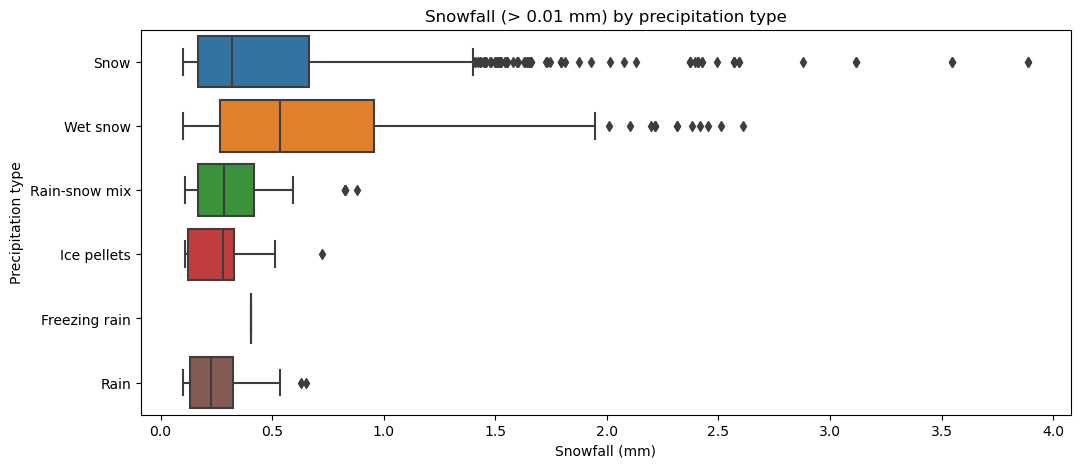

In [106]:
# Snowfall (> 0.01 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='sf', y='ptype', data=ERA5[ERA5.sf > 0.1])

plt.title('Snowfall (> 0.01 mm) by precipitation type')
plt.xlabel('Snowfall (mm)')
plt.ylabel('Precipitation type')

plt.show()

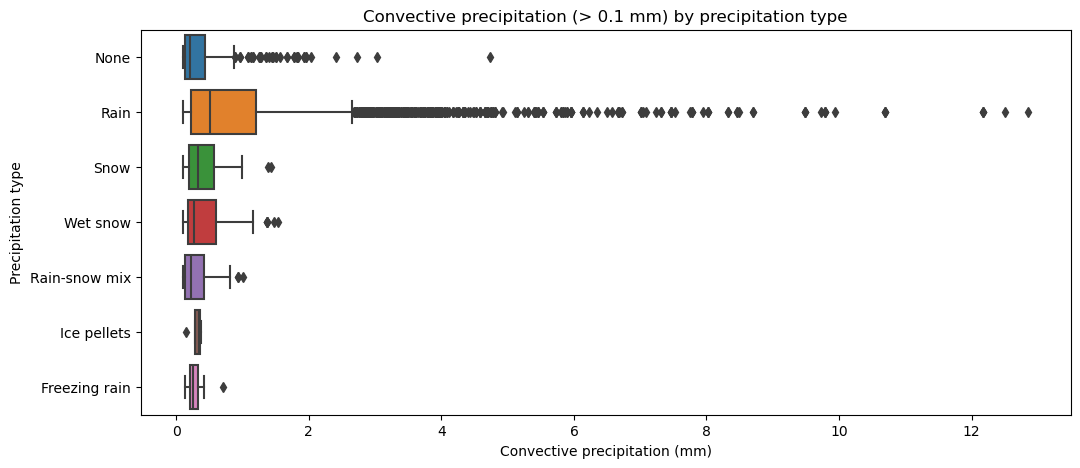

In [107]:
# Convective precipitation (> 0.01 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='cp', y='ptype', data=ERA5[ERA5.cp > 0.1])

plt.title('Convective precipitation (> 0.1 mm) by precipitation type')
plt.xlabel('Convective precipitation (mm)')
plt.ylabel('Precipitation type')

plt.show()

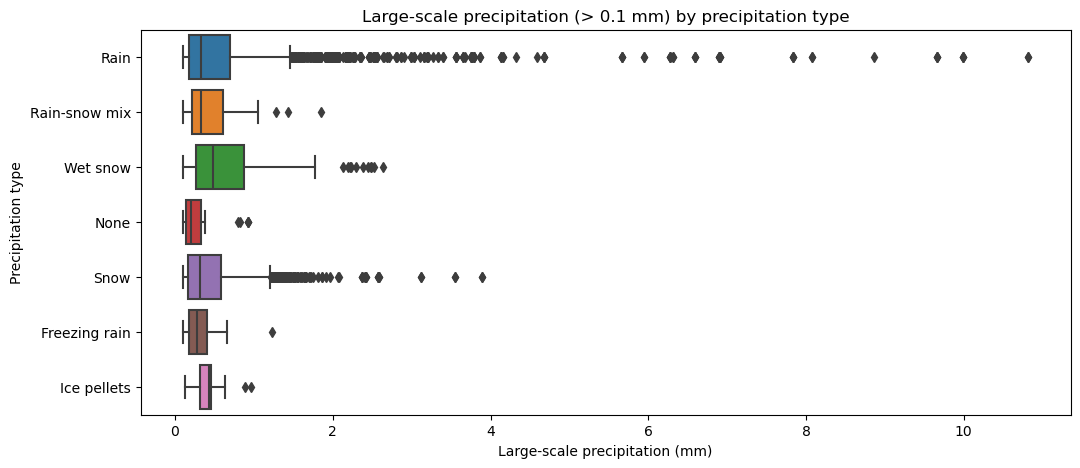

In [108]:
# Large-scale precipitation (> 0.1 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='lsp', y='ptype', data=ERA5[ERA5.lsp > 0.1])

plt.title('Large-scale precipitation (> 0.1 mm) by precipitation type')
plt.xlabel('Large-scale precipitation (mm)')
plt.ylabel('Precipitation type')

plt.show()

### Check Relationships Between Measured and ERA5 Values (Numerical)

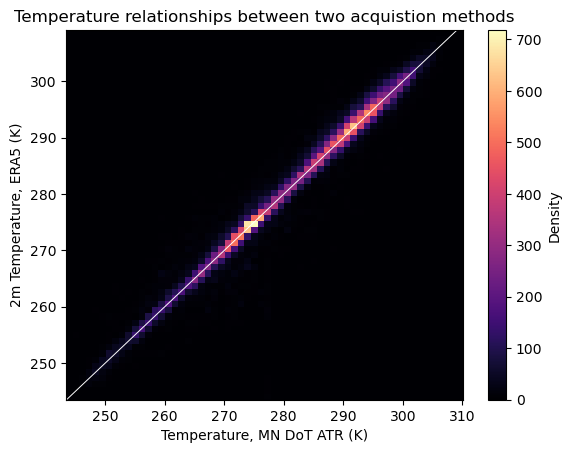

In [109]:
# Correlations between temperatures
plt.hist2d(traffic.temp, ERA5.t2m, bins=60, cmap="magma")

# Creates straight line y = x for reference
straight_line = np.linspace(240, 310, 5)
plt.plot(straight_line, straight_line, color="white", linewidth=0.7)

plt.title('Temperature relationships between two acquistion methods')
plt.colorbar(label="Density")

plt.xlabel('Temperature, MN DoT ATR (K)')
plt.ylabel('2m Temperature, ERA5 (K)')

plt.show()

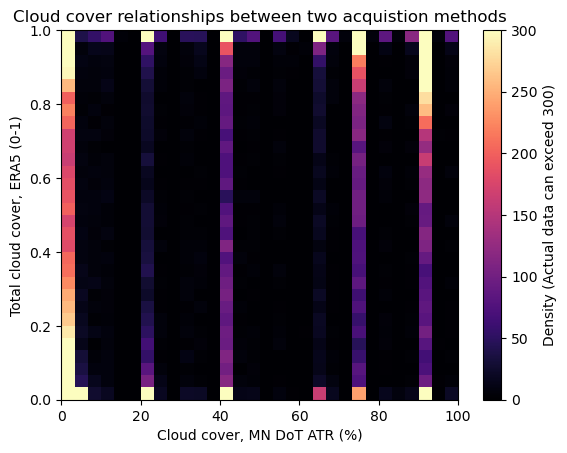

In [110]:
# Correlations between cloud coverage
plt.hist2d(traffic.clouds_all, ERA5.tcc, bins=30, vmin=0, vmax=300, cmap="magma")

plt.title('Cloud cover relationships between two acquistion methods')
plt.colorbar(label="Density (Actual data can exceed 300)")

plt.xlabel('Cloud cover, MN DoT ATR (%)')
plt.ylabel('Total cloud cover, ERA5 (0-1)')

plt.show()

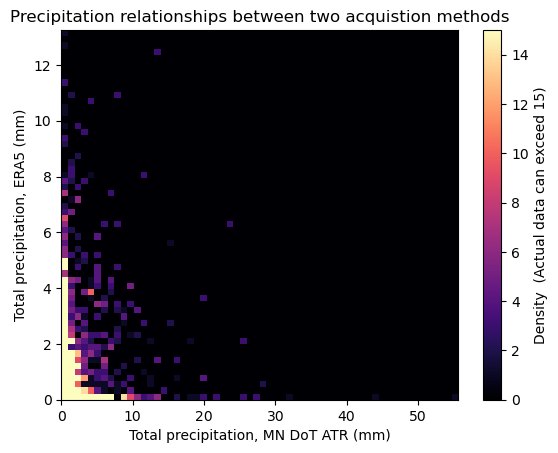

In [111]:
# Correlations between precipitation
plt.hist2d(traffic.rain_1h + traffic.snow_1h, ERA5.tp, bins=60, vmin=0, vmax=15, cmap="magma")

plt.title('Precipitation relationships between two acquistion methods')
plt.colorbar(label="Density  (Actual data can exceed 15)")

plt.xlabel('Total precipitation, MN DoT ATR (mm)')
plt.ylabel('Total precipitation, ERA5 (mm)')

plt.show()

### Check Relationships Between Measured and ERA5 Values (Categorical)

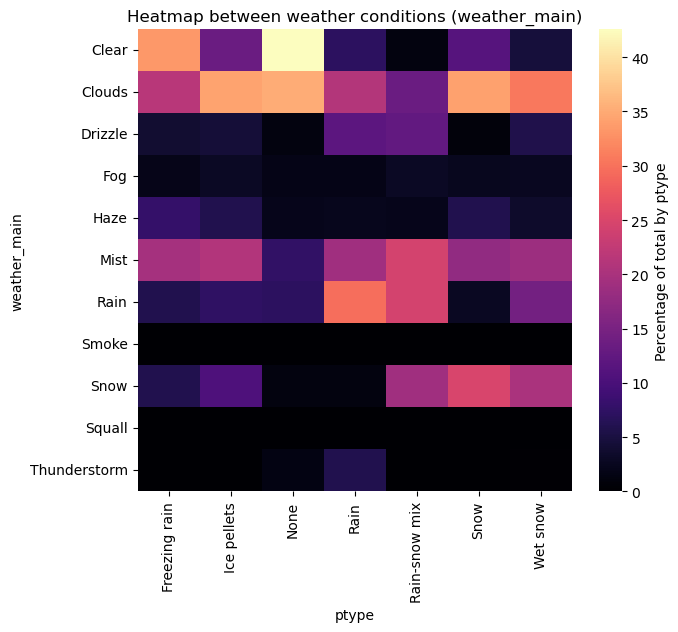

In [112]:
# Heatmap between precipitation types (weather_main)
count_matrix = pd.crosstab(traffic.weather_main, ERA5.ptype)
count_matrix = count_matrix.div(count_matrix.sum(), axis=1) * 100 # Converts values to percentage over ptype

plt.figure(figsize=(7, 6)) 
sns.heatmap(count_matrix, cmap="magma", cbar_kws={'label': 'Percentage of total by ptype'})

plt.title("Heatmap between weather conditions (weather_main)")
plt.show()

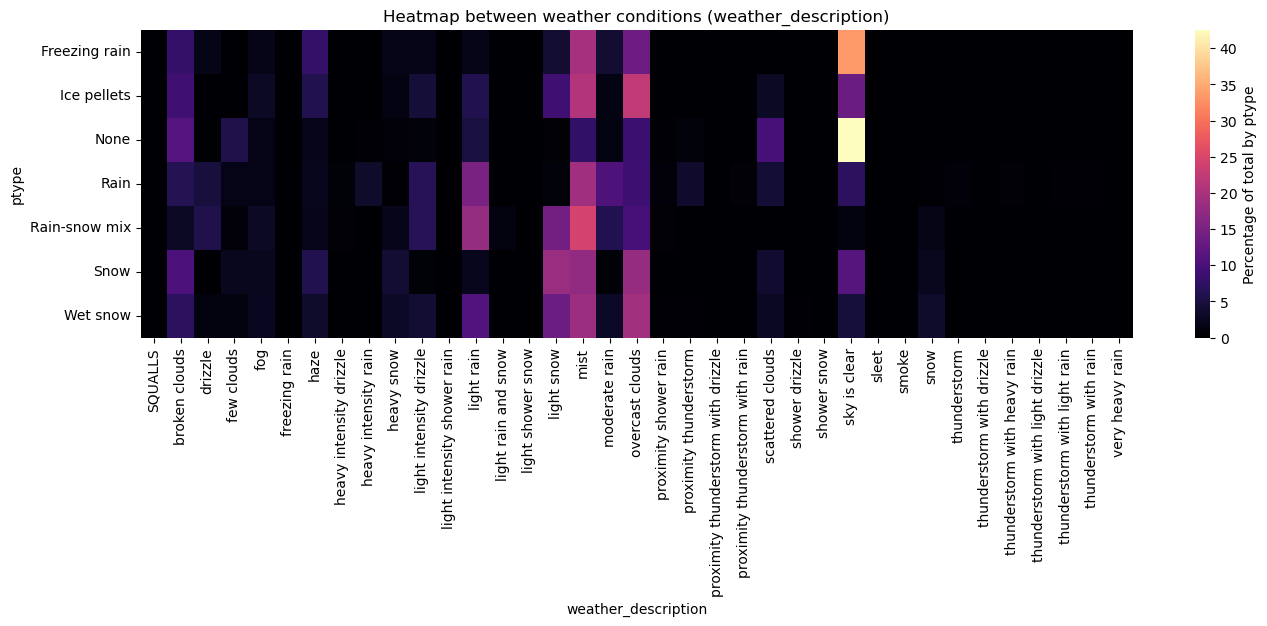

In [113]:
# Heatmap between precipitation types (weather_description)
count_matrix = pd.crosstab(traffic.weather_description, ERA5.ptype)
count_matrix = (count_matrix.div(count_matrix.sum(), axis=1) * 100).transpose() # Converts values to percentage over ptype

plt.figure(figsize=(16, 4))
sns.heatmap(count_matrix, cmap="magma", cbar_kws={'label': 'Percentage of total by ptype'})
plt.title("Heatmap between weather conditions (weather_description)")
plt.show()

### Check Relationships Between Traffic Volume and ERA5 Values

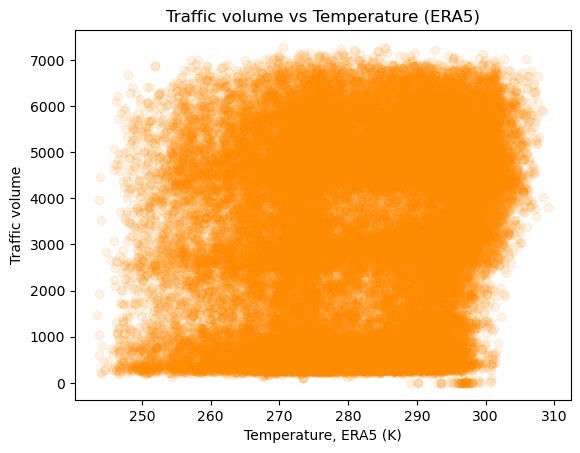

In [114]:
# Traffic volume vs Temperature
plt.scatter(ERA5.t2m, traffic.traffic_volume, color='darkorange', alpha=0.1)
plt.title('Traffic volume vs Temperature (ERA5)')

plt.xlabel('Temperature, ERA5 (K)')
plt.ylabel('Traffic volume')

plt.show()

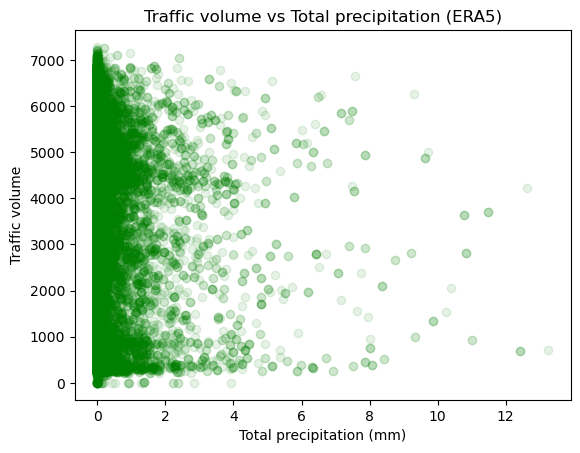

In [115]:
# Traffic volume vs Total precipitation
plt.scatter(ERA5.tp, traffic.traffic_volume, color='green', alpha=0.1)
plt.title('Traffic volume vs Total precipitation (ERA5)')

plt.xlabel('Total precipitation (mm)')
plt.ylabel('Traffic volume')

plt.show()

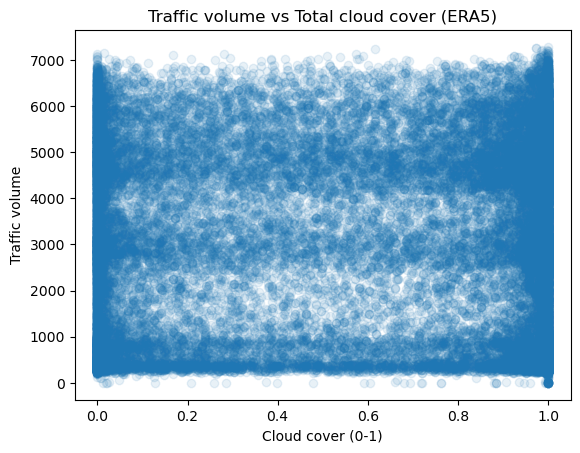

In [116]:
# Traffic volume vs Cloud coverage
plt.scatter(ERA5.tcc, traffic.traffic_volume, alpha=0.1)
plt.title('Traffic volume vs Total cloud cover (ERA5)')

plt.xlabel('Cloud cover (0-1)')
plt.ylabel('Traffic volume')

plt.show()

In [117]:
# List indicating if total precipitation exceeds 0.1 mm or not
precipitation_threshold = pd.Series((ERA5.tp > 0.1).tolist())
precipitation_threshold = precipitation_threshold.replace({False: '<= 0.1 mm',
                                                          True: '> 0.1 mm'})
precipitation_threshold.name = 'condition'

print(precipitation_threshold)

0        <= 0.1 mm
1        <= 0.1 mm
2        <= 0.1 mm
3        <= 0.1 mm
4        <= 0.1 mm
           ...    
48171     > 0.1 mm
48172    <= 0.1 mm
48173    <= 0.1 mm
48174    <= 0.1 mm
48175    <= 0.1 mm
Name: condition, Length: 48176, dtype: object


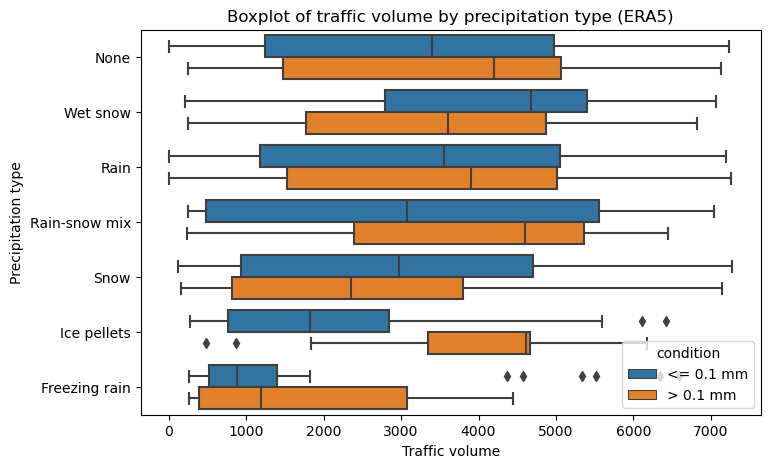

In [118]:
# Average traffic volume by precipitation type
plt.figure(figsize=(8, 5))
sns.boxplot(x='traffic_volume', y='ptype', hue='condition',
            data=pd.DataFrame([ERA5.ptype, 
                               traffic.traffic_volume,
                               precipitation_threshold]).transpose()
           )

plt.title('Boxplot of traffic volume by precipitation type (ERA5)')

plt.xlabel('Traffic volume')
plt.ylabel('Precipitation type')

plt.show()

### Time Series Between Datasets

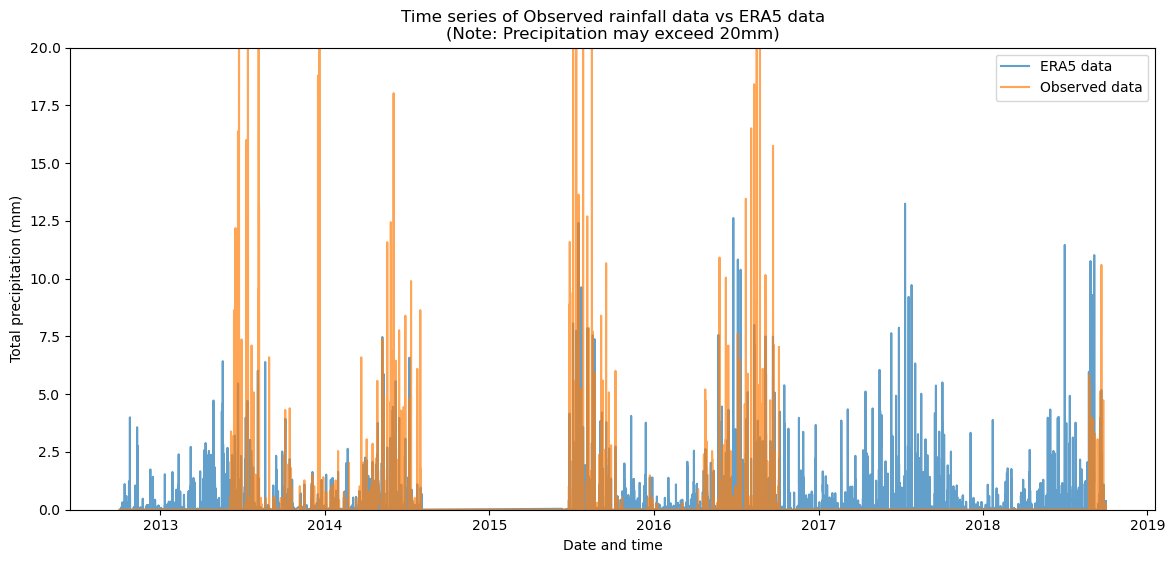

In [119]:
# Time series between observed precipiration and ERA5 precipitation
plt.figure(figsize=(14, 6))

plt.plot(ERA5.date_time, ERA5.tp, label='ERA5 data', alpha=0.7)
plt.plot(traffic.date_time, traffic.rain_1h + traffic.snow_1h, label='Observed data', alpha=0.7)

plt.title('Time series of Observed rainfall data vs ERA5 data\n(Note: Precipitation may exceed 20mm)')

plt.xlabel('Date and time')
plt.ylabel('Total precipitation (mm)')

plt.legend()
plt.ylim(0,20)

plt.show()

### Conclusions
From the extensive data exploration process above, we now know that:
- There exists a great correlation between ERA5 and observed data in terms of temperature, confirming that the datasets are at the very least, at the same general vicinity.
- There exists no apparent correlation between ERA5 and observed data in terms of cloud coverage and precipitation. This is likely due to multiple factors:
- 1. Precipitation data being "missing" in the observed data as seen from the time series
- 2. ERA5 data being a gridded average obtained from modeling rather than data observed in a single point
- 3. Either or both of the two data being unreliable in the first place.
- Weather descriptions are somewhat related. Most of the "None" ptype values of the ERA5 data aggregate at "Clear" or "Cloudy" weather, for instance.
- Interestingly, despite seeing little-to-no correlation between precipitation and traffic volume when directly plotting them against each other, if we were to partition the precipitation type by a precipitation threshold, one can see the stark difference between traffic volumes in a box plot.

# 5. Export Cleaned Data

Export `traffic`, `ERA5`, and all dummy DataFrames to `cleaned data/` for use in `data_modelling.ipynb`.

In [120]:
import os
os.makedirs('cleaned data', exist_ok=True)

# Core dataframes
traffic.to_csv('cleaned data/traffic.csv', index=False)
ERA5.to_csv('cleaned data/ERA5.csv', index=False)

# Dummy dataframes (one-hot encoded qualitative features)
dummy_holiday.to_csv('cleaned data/dummy_holiday.csv', index=False)
dummy_weaMain.to_csv('cleaned data/dummy_weaMain.csv', index=False)
dummy_weaDesc.to_csv('cleaned data/dummy_weaDesc.csv', index=False)

# Harmonic seasonality features (replaces dummy_dayOfWeek, dummy_hour, dummy_month)
dummy_seasonalities.to_csv('cleaned data/dummy_seasonalities.csv', index=False)

print('Export complete.')
print(f'dummy_seasonalities shape: {dummy_seasonalities.shape}')  # Should be (N, 30)

Export complete.
dummy_seasonalities shape: (48176, 30)
